# IndoNewsClassifier

EDA → preprocessing → baseline → transformer fine-tune → evaluation → comparison

## 1. Setup

In [1]:
import sys
from pathlib import Path

sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing import load_dataset, clean_text, light_clean_text, get_stopwords, split_dataset
from src.training import train_baseline, evaluate_baseline, save_baseline

DATA_PATH = Path('../data/raw/detik_news_title.csv')
DOCS_DIR = Path('../docs')
DOCS_DIR.mkdir(exist_ok=True)

sns.set_theme(style='whitegrid')


## 2. EDA

Class balance, title length distribution, word clouds, missing/duplicate check.

In [2]:
df_raw = pd.read_csv(DATA_PATH)

print('Shape:', df_raw.shape)
print()
print('Missing values per column:')
print(df_raw.isna().sum())
print()
n_dupes = df_raw.duplicated(subset=['title']).sum()
print(f'Duplicate titles: {n_dupes}')
print()
print('Date range:', df_raw['date'].min(), '-', df_raw['date'].max())


Shape: (91017, 4)

Missing values per column:
date        0
url         0
title       0
category    0
dtype: int64

Duplicate titles: 126

Date range: 01/01/2020 - 06/13/2020


Rows after dropping 126 duplicate titles: 90891


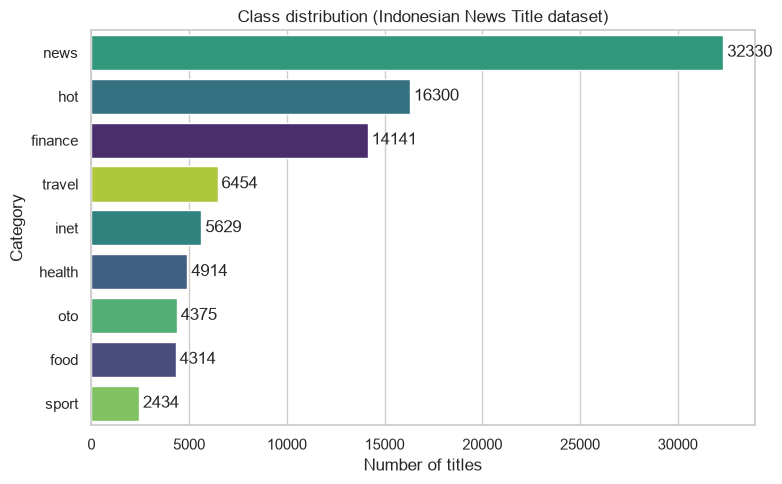

Imbalance ratio (largest/smallest class): 13.3x


In [3]:
# Drop duplicate titles before any further EDA/modeling
df = df_raw.drop_duplicates(subset=['title']).reset_index(drop=True)
print(f'Rows after dropping {n_dupes} duplicate titles: {len(df)}')

order = df['category'].value_counts().index

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, y='category', order=order, ax=ax, hue='category', palette='viridis', legend=False)
ax.set_title('Class distribution (Indonesian News Title dataset)')
ax.set_xlabel('Number of titles')
ax.set_ylabel('Category')
for i, cat in enumerate(order):
    count = (df['category'] == cat).sum()
    ax.text(count + 200, i, str(count), va='center')
plt.tight_layout()
plt.savefig(DOCS_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

imbalance_ratio = df['category'].value_counts().max() / df['category'].value_counts().min()
print(f'Imbalance ratio (largest/smallest class): {imbalance_ratio:.1f}x')


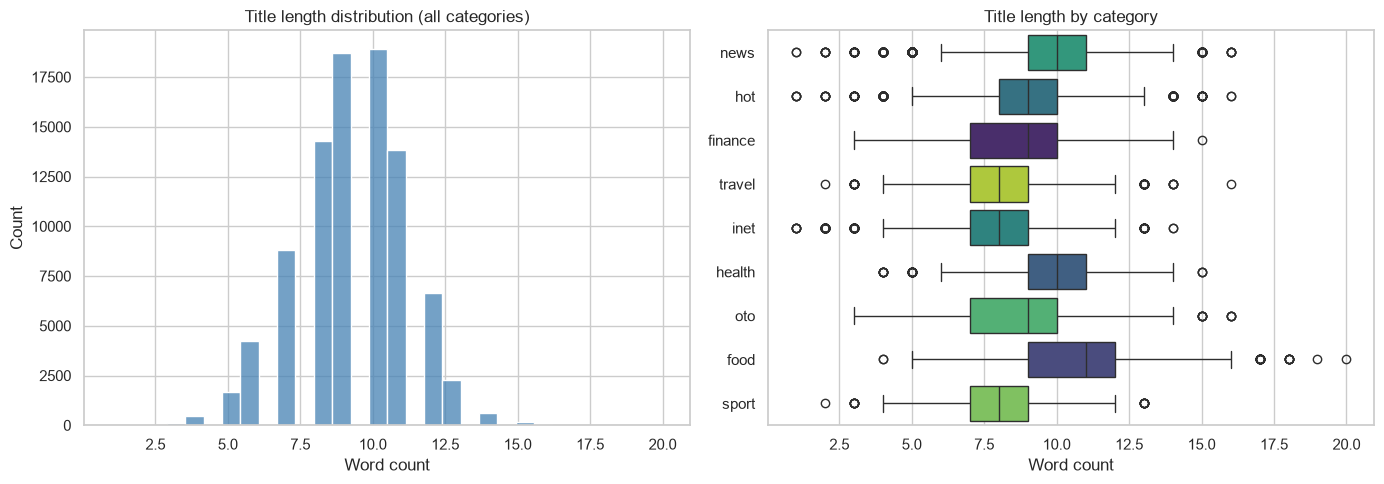

count    90891.000000
mean         9.277684
std          1.888574
min          1.000000
25%          8.000000
50%          9.000000
75%         11.000000
max         20.000000
Name: title_word_count, dtype: float64


In [4]:
df['title_word_count'] = df['title'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['title_word_count'], bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Title length distribution (all categories)')
axes[0].set_xlabel('Word count')

sns.boxplot(data=df, x='title_word_count', y='category', order=order, ax=axes[1], hue='category', palette='viridis', legend=False)
axes[1].set_title('Title length by category')
axes[1].set_xlabel('Word count')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(DOCS_DIR / 'title_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(df['title_word_count'].describe())


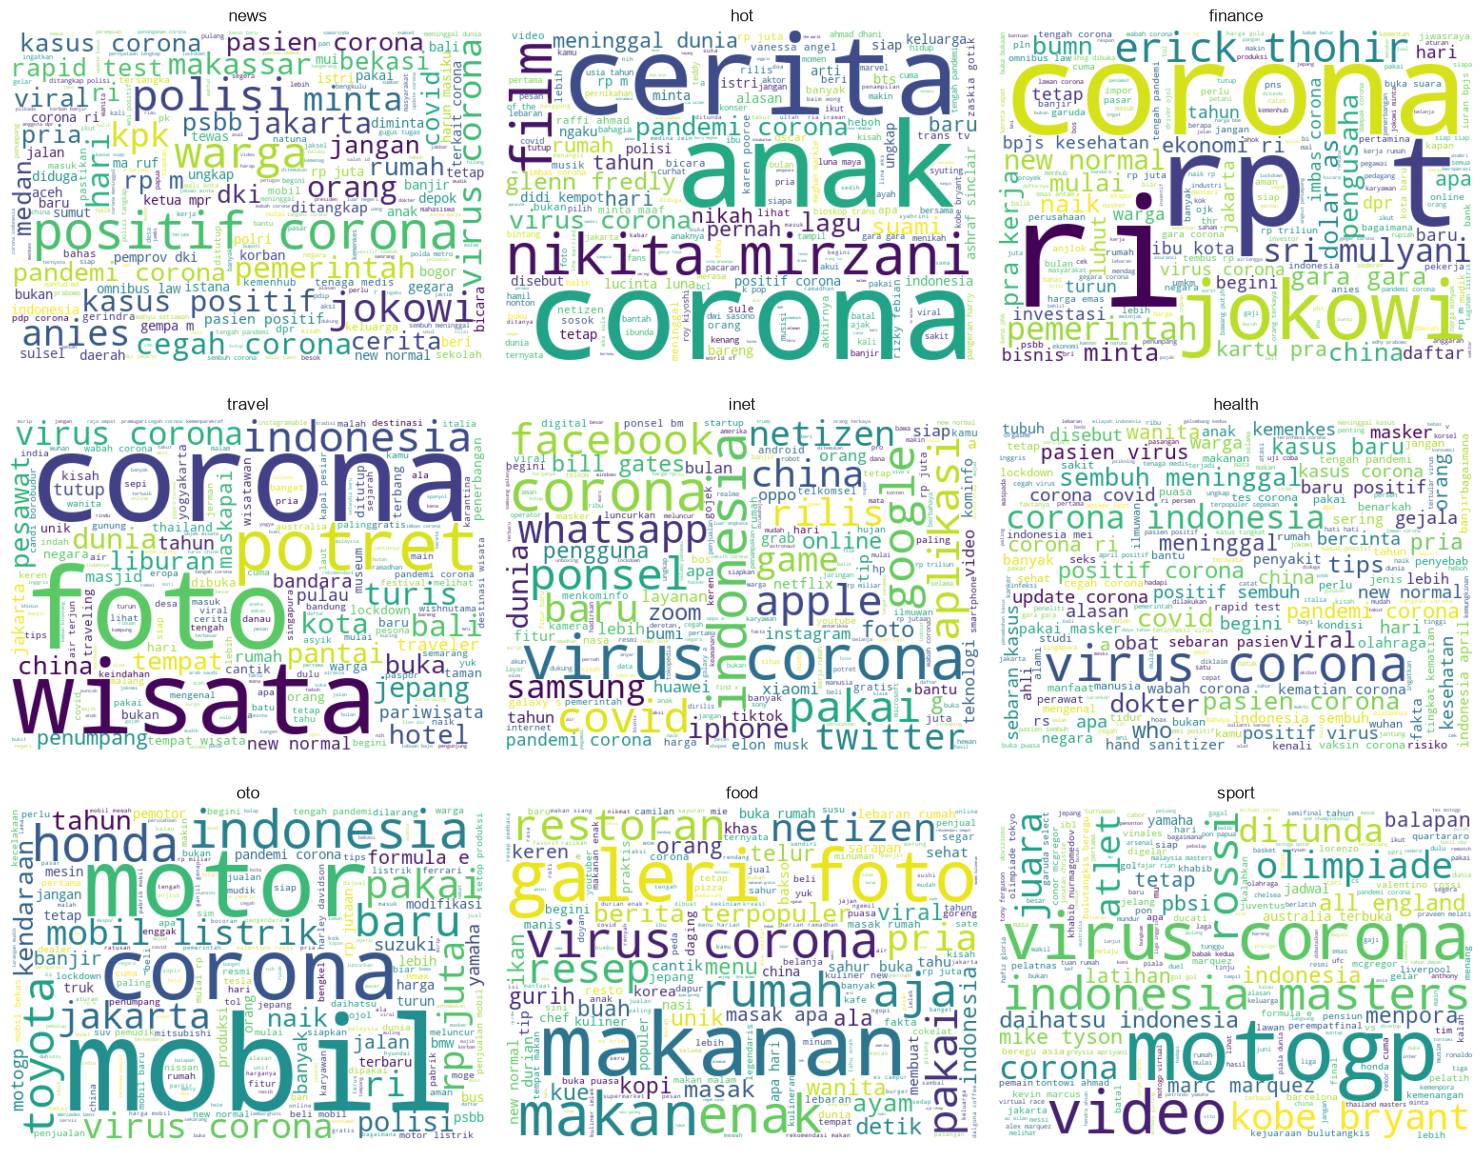

In [5]:
from wordcloud import WordCloud

id_stopwords = get_stopwords()

df['title_clean'] = df['title'].apply(lambda t: clean_text(t, stopwords=id_stopwords))

categories = order.tolist()
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for ax, cat in zip(axes.flat, categories):
    text = ' '.join(df.loc[df['category'] == cat, 'title_clean'])
    wc = WordCloud(
        width=500, height=350, background_color='white',
        stopwords=id_stopwords, colormap='viridis',
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(cat)
    ax.axis('off')

plt.tight_layout()
plt.savefig(DOCS_DIR / 'wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()


### EDA findings

- **91,017 rows → 90,891 after dropping 126 duplicate titles.** No missing values.
- **Class imbalance is significant**: `news` (32,330) vs `sport` (2,434), a ~13.3x ratio. Macro-F1 (not accuracy) is the right primary metric, and `class_weight="balanced"` is used for the baseline.
- **Data only spans Jan–Jun 2020** — the collection window overlaps COVID-19 onset in Indonesia, so "corona"/"virus"/"pandemi" appear as top words across nearly every category (finance, health, travel, sport, food, oto). This is a real limitation: the model's vocabulary is skewed toward one global event rather than representative of news in general. Noted in the final README.
- **Stopword leakage**: Sastrawi's default Indonesian stopword list missed common informal/journalistic filler words (`tak`, `jadi`, `bikin`, `soal`, `hingga`, `usai`). Extending the stopword list below before modeling.

## 3. Preprocessing

In [6]:
# title_clean: aggressively cleaned (lowercased, punctuation + stopwords stripped) for the TF-IDF baseline
# title_light_clean: URLs/whitespace only, casing and stopwords intact, for IndoBERT
df['title_clean'] = df['title'].apply(lambda t: clean_text(t, stopwords=id_stopwords))
df['title_light_clean'] = df['title'].apply(light_clean_text)

# drop titles that became empty after aggressive cleaning (all-stopword titles)
empty_after_clean = (df['title_clean'].str.len() == 0).sum()
df = df[df['title_clean'].str.len() > 0].reset_index(drop=True)
print(f'Dropped {empty_after_clean} titles that were empty after cleaning')
print(f'Final dataset size: {len(df)}')

train_df, val_df, test_df = split_dataset(df)
print(f'Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}')

train_df.to_csv('../data/processed_train.csv', index=False)
val_df.to_csv('../data/processed_val.csv', index=False)
test_df.to_csv('../data/processed_test.csv', index=False)


Dropped 0 titles that were empty after cleaning
Final dataset size: 90891
Train: 63623  Val: 13634  Test: 13634


## 4. Baseline: TF-IDF + Logistic Regression

In [7]:
baseline_pipeline = train_baseline(train_df)

val_report, val_cm, labels = evaluate_baseline(baseline_pipeline, val_df)
test_report, test_cm, _ = evaluate_baseline(baseline_pipeline, test_df)

print('=== Validation set ===')
print(f"Accuracy: {val_report['accuracy']:.4f}")
print(f"Macro F1: {val_report['macro avg']['f1-score']:.4f}")
print()
print('=== Test set ===')
print(f"Accuracy: {test_report['accuracy']:.4f}")
print(f"Macro F1: {test_report['macro avg']['f1-score']:.4f}")
print()

per_class = pd.DataFrame(test_report).T.loc[labels, ['precision', 'recall', 'f1-score', 'support']]
print('Per-class metrics (test set):')
print(per_class.round(3))


=== Validation set ===
Accuracy: 0.8267
Macro F1: 0.8022

=== Test set ===
Accuracy: 0.8282
Macro F1: 0.8008

Per-class metrics (test set):
         precision  recall  f1-score  support
finance      0.812   0.828     0.820   2122.0
food         0.808   0.841     0.824    647.0
health       0.602   0.811     0.691    737.0
hot          0.896   0.902     0.899   2445.0
inet         0.745   0.780     0.762    844.0
news         0.928   0.804     0.862   4850.0
oto          0.714   0.840     0.772    656.0
sport        0.825   0.852     0.838    365.0
travel       0.692   0.792     0.739    968.0


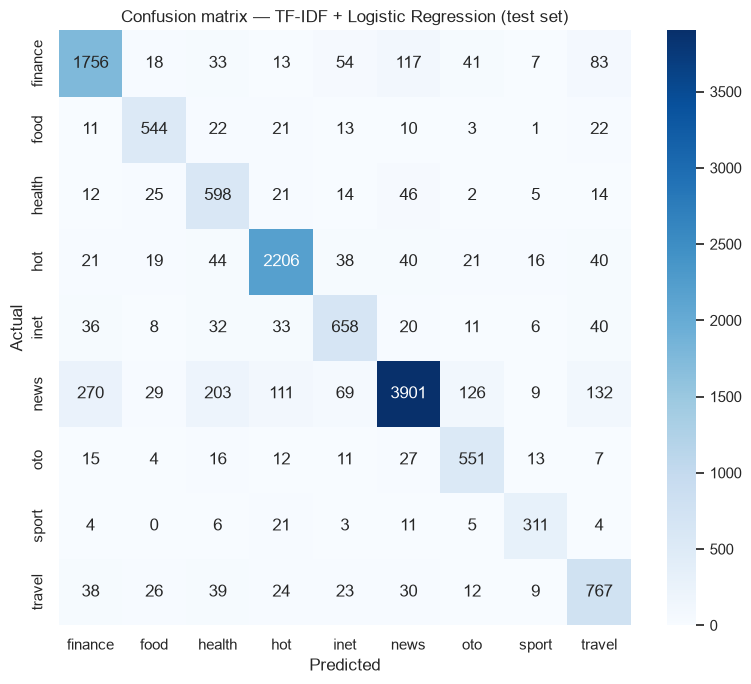

Saved baseline model to models/tfidf_logreg.joblib


In [8]:
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_title('Confusion matrix — TF-IDF + Logistic Regression (test set)')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(DOCS_DIR / 'confusion_matrix_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

Path('../models').mkdir(exist_ok=True)
save_baseline(baseline_pipeline, '../models/tfidf_logreg.joblib')
print('Saved baseline model to models/tfidf_logreg.joblib')


## 5. Transformer: IndoBERT fine-tune

**Run this section on Colab with a GPU runtime** (Runtime → Change runtime type → T4 GPU). Sections 1–4 ran fine on CPU; this section won't finish in reasonable time without a GPU.

**Before running on Colab:**
1. Push this repo to GitHub (or upload the `IndoNewsClassifier/` folder to your Colab session / Google Drive).
2. Open this notebook in Colab and run all cells from the top — Section 1's `sys.path.append('..')` and the `src` imports need to resolve, and Sections 2–4 populate `train_df`/`val_df`/`test_df`/`id_stopwords` that this section reuses.
3. The bootstrap cell below clones the repo if you're on Colab and `src/` isn't already importable; skip it if you uploaded the folder manually.

In [ ]:
# Colab bootstrap — safe to run locally too (no-op if not on Colab / src already importable)
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    try:
        import src  # noqa: F401
    except ImportError:
        get_ipython().system('git clone https://github.com/aljuhaeda/IndoNewsClassifier.git')
        get_ipython().run_line_magic('cd', 'IndoNewsClassifier/notebooks')
    get_ipython().system('pip install -q transformers datasets accelerate')

print('Running on Colab:', IN_COLAB)


In [ ]:
from src.training import train_indobert, evaluate_indobert

trainer, indobert_tokenizer, label2id, id2label = train_indobert(
    train_df, val_df,
    num_epochs=3,
    learning_rate=2e-5,
    batch_size=16,
)


In [ ]:
indobert_report, indobert_cm, indobert_labels = evaluate_indobert(
    trainer, test_df, indobert_tokenizer, label2id, id2label
)

print('=== Test set (IndoBERT) ===')
print(f"Accuracy: {indobert_report['accuracy']:.4f}")
print(f"Macro F1: {indobert_report['macro avg']['f1-score']:.4f}")
print()

indobert_per_class = pd.DataFrame(indobert_report).T.loc[indobert_labels, ['precision', 'recall', 'f1-score', 'support']]
print('Per-class metrics (test set):')
print(indobert_per_class.round(3))

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(indobert_cm, annot=True, fmt='d', cmap='Blues', xticklabels=indobert_labels, yticklabels=indobert_labels, ax=ax)
ax.set_title('Confusion matrix — IndoBERT fine-tuned (test set)')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(DOCS_DIR / 'confusion_matrix_indobert.png', dpi=150, bbox_inches='tight')
plt.show()


### Publishing the fine-tuned model

`models/indobert-news/` is gitignored (weights exceed the 100 MB commit limit). Push it to the HuggingFace Hub instead so `app.py` can load it at inference time:

```python
trainer.model.push_to_hub("aljuhaeda/indonewsclassifier-indobert")
indobert_tokenizer.push_to_hub("aljuhaeda/indonewsclassifier-indobert")
```

Requires `huggingface-cli login` (or `notebook_login()`) with a write token first.

## 6. Evaluation & comparison

In [ ]:
tfidf_vocab_size = len(baseline_pipeline.named_steps['tfidf'].vocabulary_)
logreg_coef = baseline_pipeline.named_steps['clf'].coef_
baseline_n_params = logreg_coef.size + baseline_pipeline.named_steps['clf'].intercept_.size

indobert_n_params = sum(p.numel() for p in trainer.model.parameters())

comparison = pd.DataFrame(
    {
        "Model": ["TF-IDF + Logistic Regression", "IndoBERT (fine-tuned)"],
        "Accuracy": [test_report["accuracy"], indobert_report["accuracy"]],
        "Macro F1": [test_report["macro avg"]["f1-score"], indobert_report["macro avg"]["f1-score"]],
        "Trainable params": [f"{baseline_n_params:,} (TF-IDF vocab {tfidf_vocab_size:,} x {len(labels)} classes)", f"{indobert_n_params:,}"],
        "Training hardware": ["Laptop CPU, seconds", "Colab T4 GPU, 3 epochs"],
    }
)
comparison[["Accuracy", "Macro F1"]] = comparison[["Accuracy", "Macro F1"]].round(4)
comparison


### Comparison discussion

*TODO — fill in after running Section 5 on Colab and re-executing this cell:*
- Which model wins on macro-F1, and by how much?
- Does IndoBERT's gain (if any) justify ~700x more parameters and GPU-only training for this use case?
- Which per-class weaknesses from the baseline (e.g. `health`, `travel`) does IndoBERT fix vs. inherit — cross-reference the two confusion matrices in `docs/`.
- Inference cost: baseline runs instantly on CPU; note IndoBERT's inference latency on CPU (relevant since the Streamlit app may run without a GPU).